# Weather History Analysis

#### Objective: 

The goal of this analysis is to perform a comprehensive Exploratory Data Analysis (EDA) on historical weather data to uncover seasonal patterns, feature correlations, and anomalies. 

#### Introduction

This project focuses on performing Exploratory Data Analysis (EDA) on a weather dataset to understand historical weather patterns and relationships between key meteorological variables.

**Domain:** Meteorology & Predictive Atmospheric Modeling

**Objective:** Clean, visualize, and statistically audit 10 years of historical weather observations (2006-2016) to build an optimized, model-ready dataset for predicting weather patterns

**Core Goals:**
1. Identify and fix structural data anomalies (impossible measurements, missing variables, duplicates).
2. Quantify class imbalances within categorical columns.
3. Map thermodynamic relationships (Temperature vs. Humidity).
4. Build a feature-engineering blueprint for future Machine Learning pipelines

#### **Literature Review**

#### Before running Python code, we must understand the core rules of weather science (Meteorology) approved by global bodies like NOAA. This helps us check if our data behaves correctly:

- **Thermodynamic Inversion (Temperature vs. Relative Humidity):** Warm air can hold more moisture than cold air. So, when temperature increases and the amount of moisture stays the same, relative humidity usually decreases.
- **Boundary Layer Dynamics & Wind Chill Anomalies:** Strong winds make the body lose heat faster. Because of this, the weather can feel colder than the actual air temperature.
- **Barometric Instability Indexes:** A drop in air pressure often means unstable weather conditions. It can lead to rising air, cloud formation, and sudden weather changes like cooling or rain.
- **Academic References:** - Steadman, R. G. (1984). *A Universal Scale of Apparent Temperature.* Journal of Climate and Applied Meteorology.
  - Ahrens, C. D. (2021). *Meteorology Today.* Cengage Learning.






#### Hypotheses to Test:
##### H_1 (Temperature vs. Humidity): There is a strong negative correlation between Temperature and Relative Humidity.
##### H_2 (Apparent Temperature vs. Actual Temperature): High wind speeds significantly increase the variance between Actual Temperature and Apparent Temperature (Wind Chill effect).
##### H_3 (Seasonality): Humidity levels show a statistically significant variation across different seasons

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv('WeatherHistory.csv.zip')
df.sample(5)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
17556,2008-04-01 12:00:00.000 +0200,Mostly Cloudy,rain,11.222222,11.222222,0.50,14.3612,350.0,9.9820,0.0,1017.11,Mostly cloudy starting in the morning.
59471,2012-11-02 00:00:00.000 +0100,Mostly Cloudy,rain,9.494444,7.916667,0.96,10.7226,161.0,9.9820,0.0,1002.95,Foggy in the morning.
69073,2013-10-24 02:00:00.000 +0200,Partly Cloudy,rain,15.827778,15.827778,0.77,15.8907,161.0,15.0213,0.0,1019.97,Partly cloudy throughout the day.
92299,2016-06-18 22:00:00.000 +0200,Partly Cloudy,rain,20.277778,20.277778,0.74,10.8836,18.0,16.1000,0.0,1015.45,Partly cloudy throughout the day.
79360,2015-04-26 19:00:00.000 +0200,Partly Cloudy,rain,21.177778,21.177778,0.48,7.8085,225.0,16.1000,0.0,1008.79,Partly cloudy until evening.


In [3]:
#  plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


# Feature Understanding

### **Formatted Date**
#### Represents the timestamp of the weather observation. This feature helps analyze seasonal patterns, yearly trends, monthly temperature variations, and time-based weather changes.
### **Summary**
#### A short textual description of the weather condition such as Clear, Partly Cloudy, Foggy, or Rainy. It provides a quick overview of the atmospheric situation.
### **Precip Type**
#### Indicates the type of precipitation occurring during the observation, mainly rain or snow. This feature is useful for understanding weather severity and seasonal precipitation trends.
### **Temperature (C)**
#### The actual recorded air temperature in Celsius. This is one of the most important weather variables and strongly influences humidity, visibility, pressure, and human comfort.
### **Apparent Temperature (C)**
#### Also known as the “feels like” temperature. It considers the combined effects of wind speed and humidity on human perception of temperature. During windy or humid conditions, apparent temperature may differ significantly from actual temperature.
### **Humidity**
#### Measures the amount of moisture present in the air, usually ranging between 0 and 1. High humidity is often associated with cloudy or rainy conditions, while low humidity is linked with dry weather.
### **Wind Speed (km/h)**
#### Represents how fast the wind is moving. Wind speed plays an important role in temperature perception, storm formation, and visibility conditions.
### **Wind Bearing (degrees)**
#### Indicates the direction from which the wind is blowing, measured in degrees. This feature can help identify dominant wind directions and seasonal airflow patterns.
### **Visibility (km)**
#### Measures how far objects can be clearly seen. Fog, rain, snow, or pollution generally reduce visibility. This feature is especially important in transportation and aviation studies.
### **Cloud Cover (written as “Loud Cover” in your dataset, likely a typo)**
#### **“Cloud Cover” is a standard weather feature, while “Loud Cover” has no meaning in meteorology. Also, the column values range between 0 and 1, which matches how cloud cover is measured.**
#### Represents the fraction of the sky covered by clouds. Higher cloud cover is usually associated with lower sunlight exposure and cooler daytime temperatures.
### **Pressure (millibars)**
#### Atmospheric pressure measured in millibars. Pressure variations are closely linked with changing weather systems. Low pressure often indicates storms or rainfall, while high pressure is commonly associated with clear skies.
### **Daily Summary**
#### A broader textual description summarizing the weather conditions throughout the day. This feature can be useful for natural language insights and weather categorization.

# Sources / References

#### The following sources were referred to for understanding weather variables, meteorological terminology, and literature related to weather data analysis

##### https://www.noaa.gov
##### https://www.visualcrossing.com
##### https://dev.to

# Data Understanding

#### This section focuses on understanding the structure, quality, and basic characteristics of the dataset before starting cleaning or visualization

# Dataset Shape

In [4]:
df.shape

(96453, 12)

#### The datset contains 96453 rows and 12 columns.

# Preview the Dataset 

In [5]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [6]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


#### The dataset contains both numerical and categorical features related to weather conditions such as temperature, humidity, pressure, wind speed, and weather summaries. Initial inspection shows that the dataset is structured properly

# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


#### Some columns contain missing values that may require preprocessing.

# Statistical Summary of Numerical Features

In [8]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


#### The numerical weather features have different ranges and variations. Some features like temperature, wind speed, and pressure may contain extreme values or high variability.


# Check Missing Values

In [9]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

#### Precip Type contain missing values.These missing values will need to be handled during the data cleaning stage. 

# Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(24)

#### The dataset contains duplicate observations which may affect analysis and should be handled  during preprocessing

# **Final Summary for Data Understanding Section**

#### The initial analysis shows that the dataset is properly organized and contains both numerical and categorical weather features. Some missing values or duplicate may be present, which will be handled during data cleaning before detailed analysis.

# Data Cleaning

#### This section focuses on identifying and fixing issues in the dataset before starting detailed analysis and visualization.

# Check Column Names

In [11]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

# Rename Incorrect Columns

#### As mentioned earlier, “Loud Cover” appears to be a typing error, so the column name is being changed from “Loud Cover” to “Cloud Cover”.
   

In [12]:
df.rename(columns={'Loud Cover':'Cloud Cover'}, inplace=True)

In [13]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Cloud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

# Convert Date Column into Datetime Format

In [14]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

df['year'] = df['Formatted Date'].dt.year
df['month'] = df['Formatted Date'].dt.month
df['day'] = df['Formatted Date'].dt.day
df['hour'] = df['Formatted Date'].dt.hour
df['local_date'] = df['Formatted Date'].dt.tz_convert('Asia/Kolkata')

In [15]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Cloud Cover',
       'Pressure (millibars)', 'Daily Summary', 'year', 'month', 'day', 'hour',
       'local_date'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype                       
---  ------                    --------------  -----                       
 0   Formatted Date            96453 non-null  datetime64[ns, UTC]         
 1   Summary                   96453 non-null  object                      
 2   Precip Type               95936 non-null  object                      
 3   Temperature (C)           96453 non-null  float64                     
 4   Apparent Temperature (C)  96453 non-null  float64                     
 5   Humidity                  96453 non-null  float64                     
 6   Wind Speed (km/h)         96453 non-null  float64                     
 7   Wind Bearing (degrees)    96453 non-null  float64                     
 8   Visibility (km)           96453 non-null  float64                     
 9   Cloud Cover               96453 non-null  float64 

#### The “Formatted Date” column was converted into datetime format to enable proper time-based analysis and trend extraction

# Handle Missing Values

In [17]:
df.sample(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Cloud Cover,Pressure (millibars),Daily Summary,year,month,day,hour,local_date
12260,2007-01-31 19:00:00+00:00,Mostly Cloudy,rain,0.233333,-3.227778,0.84,10.8353,200.0,9.9820,0.0,1019.18,Partly cloudy throughout the day.,2007,1,31,19,2007-02-01 00:30:00+05:30
14187,2007-03-21 02:00:00+00:00,Overcast,rain,3.355556,1.644444,0.95,6.6171,288.0,14.9569,0.0,993.53,Mostly cloudy until evening.,2007,3,21,2,2007-03-21 07:30:00+05:30
45414,2011-12-13 05:00:00+00:00,Overcast,rain,7.061111,7.061111,0.93,2.7692,200.0,5.9248,0.0,1015.27,Foggy starting in the evening.,2011,12,13,5,2011-12-13 10:30:00+05:30
48174,2011-07-08 04:00:00+00:00,Clear,rain,18.827778,18.827778,0.84,9.4346,141.0,9.9820,0.0,1013.37,Partly cloudy starting in the morning continui...,2011,7,8,4,2011-07-08 09:30:00+05:30
12471,2007-07-11 13:00:00+00:00,Mostly Cloudy,rain,22.266667,22.266667,0.35,8.1627,313.0,11.2056,0.0,1010.98,Mostly cloudy until night.,2007,7,11,13,2007-07-11 18:30:00+05:30
12275,2007-01-04 10:00:00+00:00,Mostly Cloudy,rain,2.894444,0.666667,0.88,8.0339,199.0,9.9820,0.0,1023.95,Mostly cloudy until night.,2007,1,4,10,2007-01-04 15:30:00+05:30
70900,2014-08-10 02:00:00+00:00,Clear,rain,17.266667,17.266667,0.93,0.0000,0.0,7.8729,0.0,1015.10,Partly cloudy starting in the morning.,2014,8,10,2,2014-08-10 07:30:00+05:30
29308,2009-01-13 03:00:00+00:00,Overcast,snow,-6.111111,-9.433333,0.92,6.8747,91.0,3.5098,0.0,1032.64,Foggy starting in the morning continuing until...,2009,1,13,3,2009-01-13 08:30:00+05:30
19337,2008-12-21 16:00:00+00:00,Partly Cloudy,rain,2.405556,-0.783333,0.78,11.5920,293.0,9.9820,0.0,1025.05,Partly cloudy starting overnight continuing un...,2008,12,21,16,2008-12-21 21:30:00+05:30
17544,2008-03-31 22:00:00+00:00,Clear,rain,6.383333,5.133333,0.66,6.6493,351.0,15.8263,0.0,1016.81,Mostly cloudy starting in the morning.,2008,3,31,22,2008-04-01 03:30:00+05:30


# Handle Missing Values

In [18]:
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])

#### As observed in the data understanding section, the “Precip Type” column contained some missing values. Since it is a categorical feature with rain as the most frequently occurring category, the missing values were replaced using the mode of the column.


# Check Duplicate Rows

In [19]:
df.duplicated().sum()

np.int64(24)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

#### Duplicate rows were removed because repeated observations can create redundancy and may affect the accuracy of analysis and visualizations

# Final Summary for Data Cleaning

#### After data cleaning, the dataset became more consistent and ready for exploratory analysis. Missing values were handled, incorrect column names were fixed

# **Univariate Analysis**

#### In  Univariate analysis we anaylsis one column at a time” 
#### We focus on:
#### Distribution,
#### Central tendency (mean/median)
#### Spread (std, range)
#### Skewness
#### Outliers
#### Dominant categories (for categorical data)

In [22]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Cloud Cover',
       'Pressure (millibars)', 'Daily Summary', 'year', 'month', 'day', 'hour',
       'local_date'],
      dtype='object')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96429 entries, 0 to 96452
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype                       
---  ------                    --------------  -----                       
 0   Formatted Date            96429 non-null  datetime64[ns, UTC]         
 1   Summary                   96429 non-null  object                      
 2   Precip Type               96429 non-null  object                      
 3   Temperature (C)           96429 non-null  float64                     
 4   Apparent Temperature (C)  96429 non-null  float64                     
 5   Humidity                  96429 non-null  float64                     
 6   Wind Speed (km/h)         96429 non-null  float64                     
 7   Wind Bearing (degrees)    96429 non-null  float64                     
 8   Visibility (km)           96429 non-null  float64                     
 9   Cloud Cover               96429 non-null  float64      

# Analysis categorical columns

## Summary

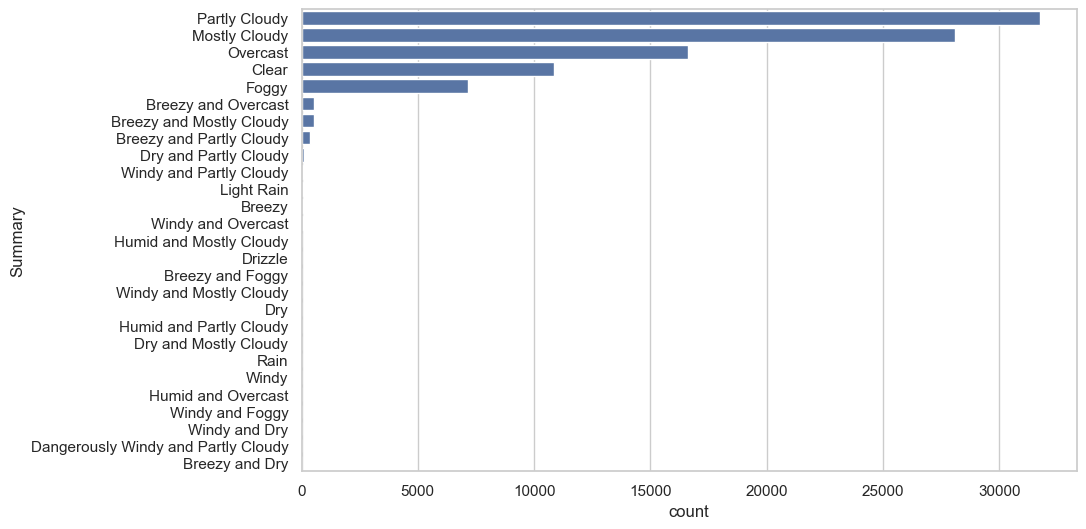

In [24]:
sns.countplot(y=df['Summary'], order=df['Summary'].value_counts().index)
plt.show()

In [25]:
df['Summary'].value_counts()

Summary
Partly Cloudy                          31726
Mostly Cloudy                          28094
Overcast                               16597
Clear                                  10873
Foggy                                   7148
Breezy and Overcast                      528
Breezy and Mostly Cloudy                 516
Breezy and Partly Cloudy                 386
Dry and Partly Cloudy                     86
Windy and Partly Cloudy                   67
Light Rain                                63
Breezy                                    54
Windy and Overcast                        45
Humid and Mostly Cloudy                   40
Drizzle                                   39
Breezy and Foggy                          35
Windy and Mostly Cloudy                   35
Dry                                       34
Humid and Partly Cloudy                   17
Dry and Mostly Cloudy                     14
Rain                                      10
Windy                                      8
Hu

In [26]:
print('Unique weather Summaries:',df['Summary'].nunique())

Unique weather Summaries: 27


#### Total observations: 96,429. Data is highly imbalanced across weather conditions.
#### Dominant Weather Conditions
#### Top weather states:
#### Partly Cloudy → 31,726 (~33%)
#### Mostly Cloudy → 28,094 (~29%)
#### Overcast → 16,597 (~17%)
#### Clear → 10,873 (~11%)
#### Foggy → 7,148 (~7%)
#### These 5 categories alone cover ~95%+ of data
#### The weather summary distribution is highly skewed toward stable atmospheric conditions such as partly cloudy, mostly cloudy, and overcast. Rare weather events like rain, drizzle, and windy conditions appear infrequently, indicating a strong class imbalance in weather patterns.

## Precip Type

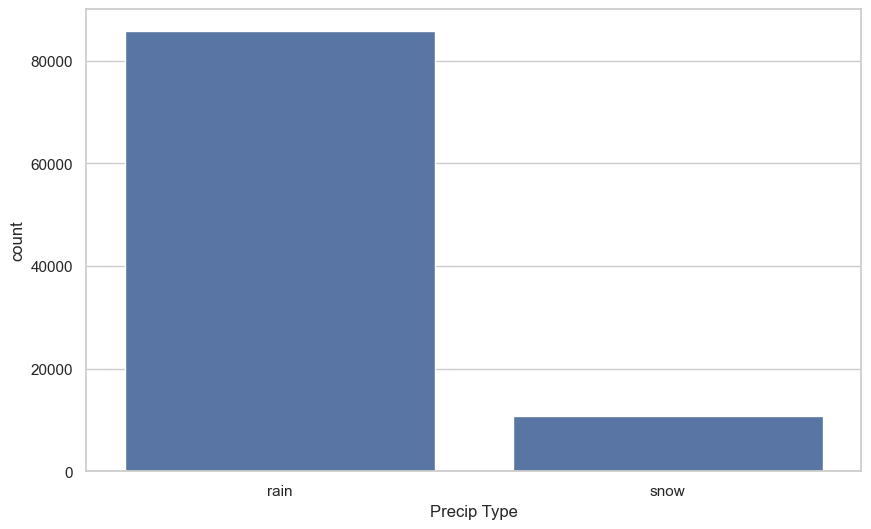

In [27]:
sns.countplot(x=df['Precip Type'])
plt.show()

In [28]:
df['Precip Type'].value_counts()

Precip Type
rain    85717
snow    10712
Name: count, dtype: int64

#### Precipitation in this dataset is heavily rain-dominated.Snow is present but relatively rare, indicating seasonal or climate-specific variation

## Daily Summary 

In [29]:
df['Daily Summary'].value_counts().head()

Daily Summary
Mostly cloudy throughout the day.         20085
Partly cloudy throughout the day.          9981
Partly cloudy until night.                 6169
Partly cloudy starting in the morning.     5184
Foggy in the morning.                      4201
Name: count, dtype: int64

In [30]:
df['Daily Summary'].nunique()

214

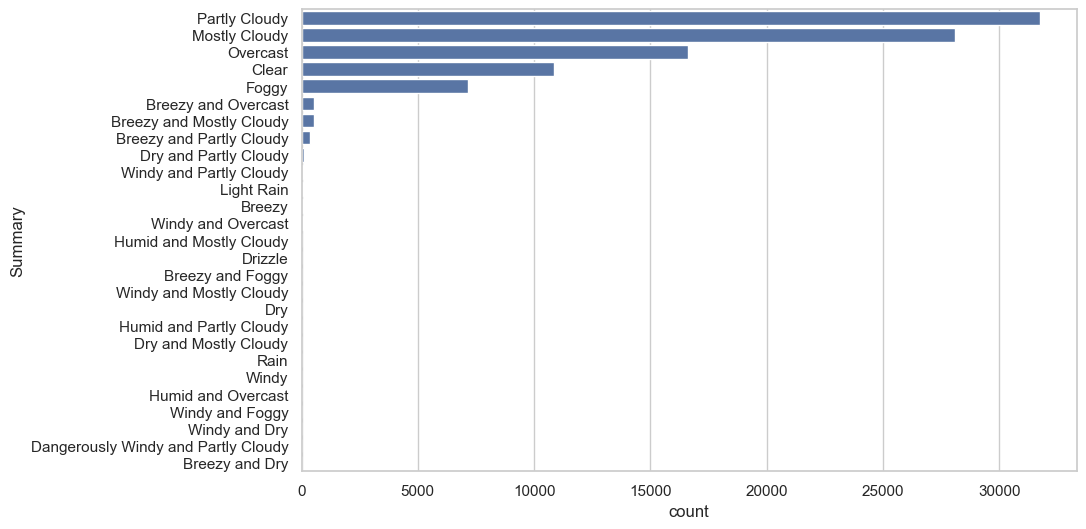

In [31]:
sns.countplot(y=df['Summary'], order=df['Summary'].value_counts().index)
plt.show()

#### The dataset is strongly skewed toward cloud-dominated daily weather pattes. Weather is often stable or slowly changing rather than extreme. Fog appears as a secondary recurring morning condition

## Month (time feature)

<Axes: xlabel='month', ylabel='count'>

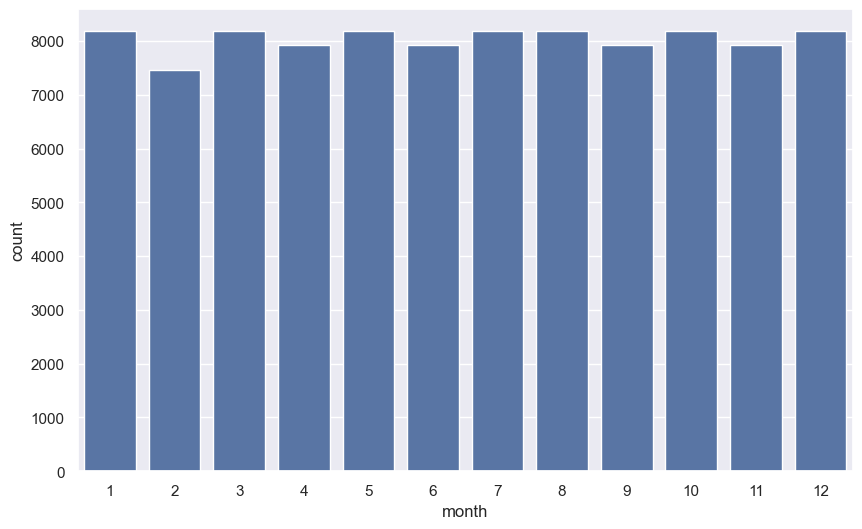

In [32]:
sns.set_style()
sns.set_theme(style='darkgrid')
sns.countplot(x='month',data=df)

In [33]:
df['month'].value_counts()

month
3     8184
8     8184
12    8184
1     8184
5     8184
10    8184
7     8181
4     7920
11    7920
6     7920
9     7920
2     7464
Name: count, dtype: int64

#### Monthly distribution is mostly balanced with minor variation. February has fewer records, likely due to fewer calendar day

## Hour

<Axes: xlabel='hour', ylabel='count'>

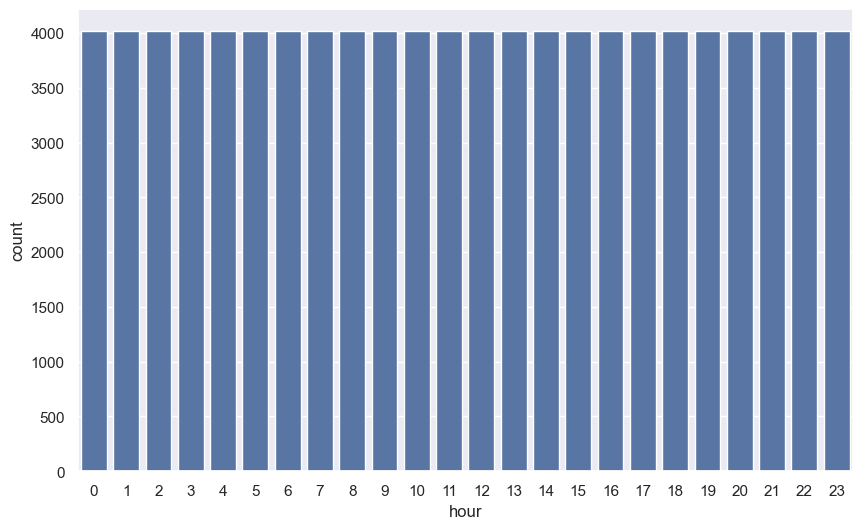

In [34]:
sns.countplot(x='hour',data=df)

In [35]:
df['hour'].value_counts()

hour
10    4018
11    4018
20    4018
19    4018
18    4018
17    4018
16    4018
15    4018
14    4018
13    4018
12    4018
21    4018
9     4018
8     4018
7     4018
6     4018
5     4018
4     4018
3     4018
2     4018
1     4018
23    4017
0     4017
22    4017
Name: count, dtype: int64

#### The hourly data is highly balanced

## Analysis numerical columns

## Temperature (C)           

<Axes: xlabel='Temperature (C)', ylabel='Count'>

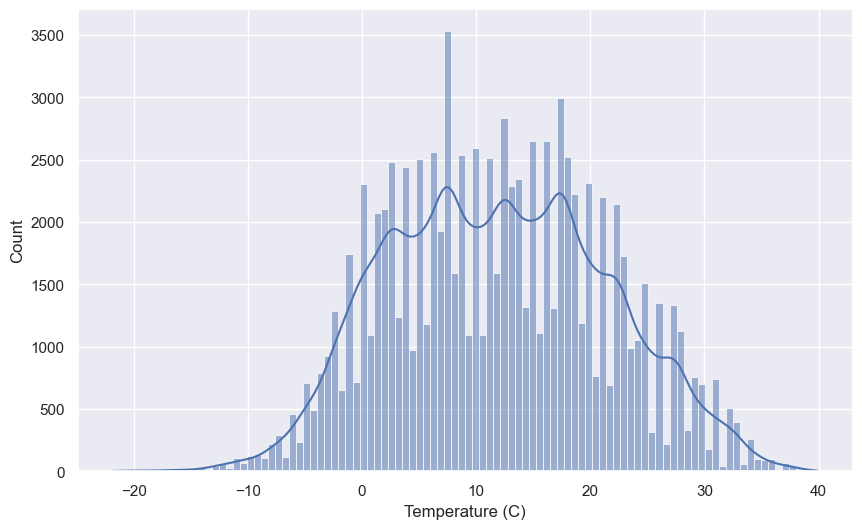

In [36]:
sns.histplot(x='Temperature (C)',data=df,kde=True)

In [37]:
df['Temperature (C)'].describe()

count    96429.000000
mean        11.929692
std          9.550492
min        -21.822222
25%          4.683333
50%         12.000000
75%         18.838889
max         39.905556
Name: Temperature (C), dtype: float64

#### The dataset represents a well-distributed seasonal climate pattern, with most observations in the mild range, but also capturing extreme winter and summer conditions, making it suitable for comprehensive weather analysis.

## Apparent Temperature (C)  

<Axes: xlabel='Apparent Temperature (C)', ylabel='Count'>

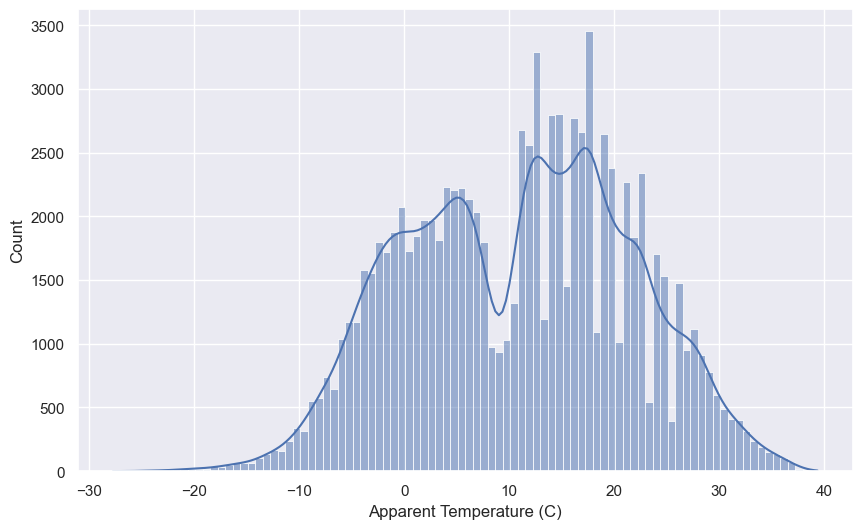

In [38]:
sns.histplot(x='Apparent Temperature (C)',data=df,kde=True)

In [39]:
df['Apparent Temperature (C)'].describe()

count    96429.000000
mean        10.851707
std         10.695743
min        -27.716667
25%          2.311111
50%         12.000000
75%         18.838889
max         39.344444
Name: Apparent Temperature (C), dtype: float64

#### The dataset shows that the feels-like temperature usually stays mild, but it can sometimes go to very cold or very hot levels. This means the weather changes a lot and is useful for studying how people actually experience temperature.

## Humidity 

<Axes: xlabel='Humidity', ylabel='Count'>

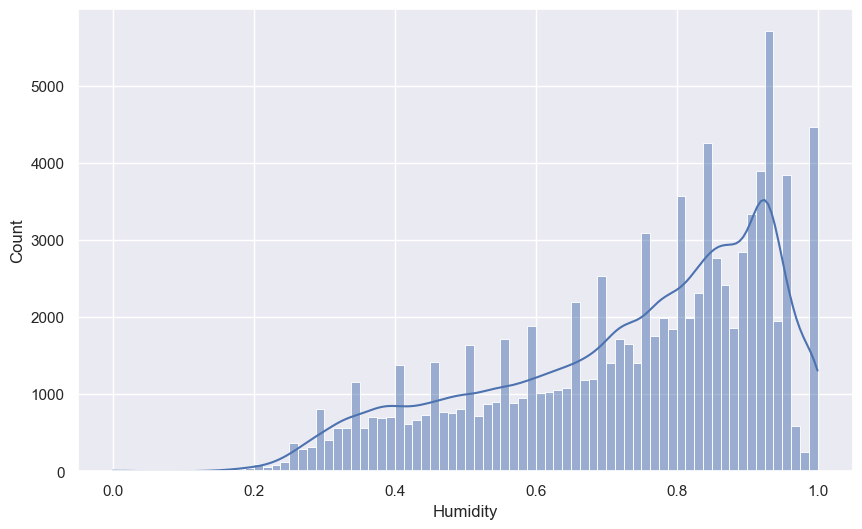

In [40]:
sns.histplot(x='Humidity',data=df,kde=True)

In [41]:
df['Humidity'].describe()

count    96429.000000
mean         0.734902
std          0.195466
min          0.000000
25%          0.600000
50%          0.780000
75%          0.890000
max          1.000000
Name: Humidity, dtype: float64

#### Humidity is mostly in the moderate to high range (0.6 to 0.89).Very low humidity conditions are rare. Overall, the dataset shows that the environment is generally moderately to highly humid, with occasional dry and fully humid conditions.

## Wind Speed (km/h)         

<Axes: xlabel='Wind Speed (km/h)', ylabel='Count'>

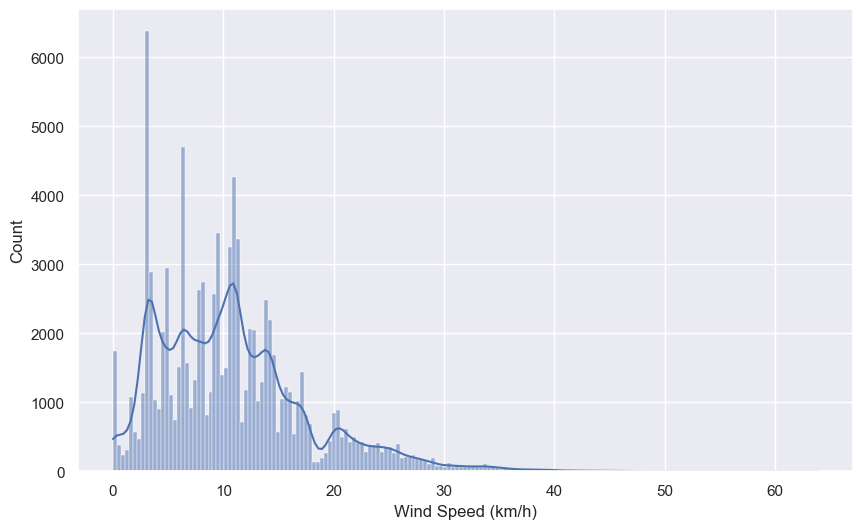

In [42]:
sns.histplot(x='Wind Speed (km/h)',data=df,kde=True)

In [43]:
df['Wind Speed (km/h)'].describe()

count    96429.000000
mean        10.812460
std          6.913345
min          0.000000
25%          5.828200
50%          9.965900
75%         14.135800
max         63.852600
Name: Wind Speed (km/h), dtype: float64

#### Most wind speeds lie between 5.83 km/h and 14.13 km/h, showing stable and moderate wind conditions.Very high wind speeds are rare but present, indicating occasional extreme weather events.Overall, the dataset represents mostly calm to moderate wind conditions, with a few high wind outliers, making it useful for analyzing both normal and extreme wind patterns.

## Wind Bearing (degrees)    

<Axes: xlabel='Wind Bearing (degrees)', ylabel='Count'>

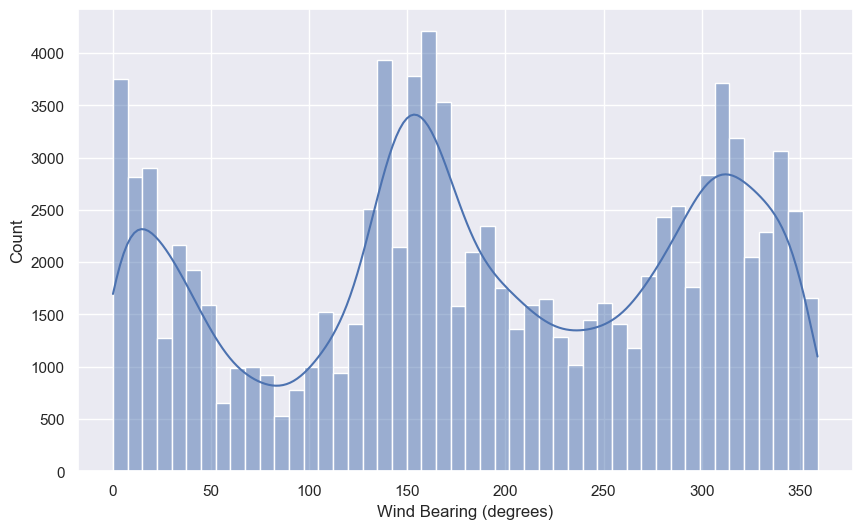

In [44]:
sns.histplot(x='Wind Bearing (degrees)',data=df,kde=True)

In [45]:
df['Wind Bearing (degrees)'].describe()

count    96429.000000
mean       187.497506
std        107.376423
min          0.000000
25%        116.000000
50%        180.000000
75%        290.000000
max        359.000000
Name: Wind Bearing (degrees), dtype: float64

#### The Wind Bearing (degrees) feature represents wind direction on a circular scale ranging from 0° to 359°.Both mean and median are close to 180° (South).This suggests a slight central tendency toward southern wind directions.The small difference between mean and median indicates fairly balanced distribution around the center.
#### Wind direction in this dataset is highly diverse and spread across all compass directions, with a mild tendency toward southern directions around 180°, but no strong or dominant wind direction pattern is present.

##  Visibility (km)           

<Axes: xlabel='Visibility (km)', ylabel='Count'>

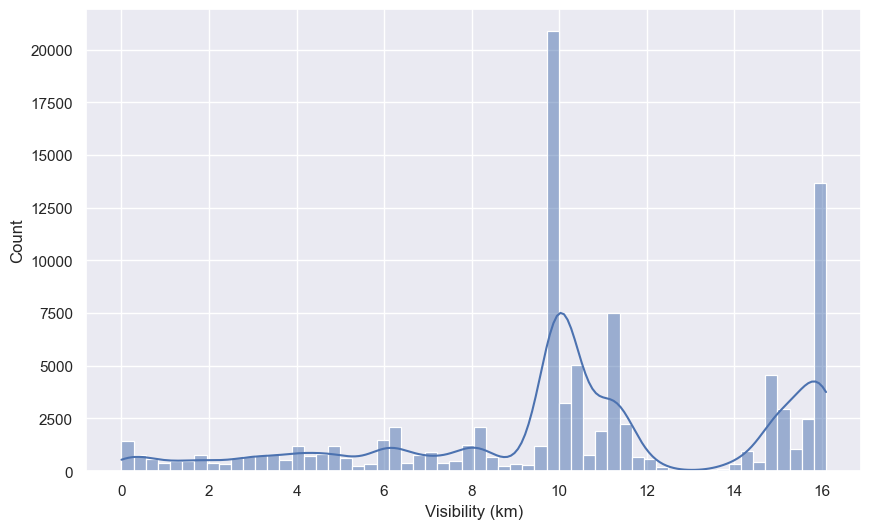

In [46]:
sns.histplot(x='Visibility (km)',data=df,kde=True)

In [47]:
df['Visibility (km)'].describe()

count    96429.000000
mean        10.347225
std          4.192548
min          0.000000
25%          8.339800
50%         10.046400
75%         14.812000
max         16.100000
Name: Visibility (km), dtype: float64

#### 0 km suggests extreme fog or near-zero visibility conditions. 16.1 km indicates very clear atmospheric conditions.Wide range shows presence of both extreme and normal conditions.Atmospheric clarity is moderate and stable most of the time.
#### Visibility in this dataset is generally moderate (~10 km on average) with balanced variation across conditions. While most observations reflect normal atmospheric clarity, occasional extreme low and high visibility conditions indicate changing weather patterns influenced by environmental factors.

## Cloud Cover        

In [48]:
df['Cloud Cover'].describe()

count    96429.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Cloud Cover, dtype: float64

#### The Cloud Cover feature contains a single constant value (0.0) across all 96,429 records. As a result, it has no variability and no analytical or predictive value in its current form.

## Pressure (millibars)      

<Axes: xlabel='Pressure (millibars)', ylabel='Count'>

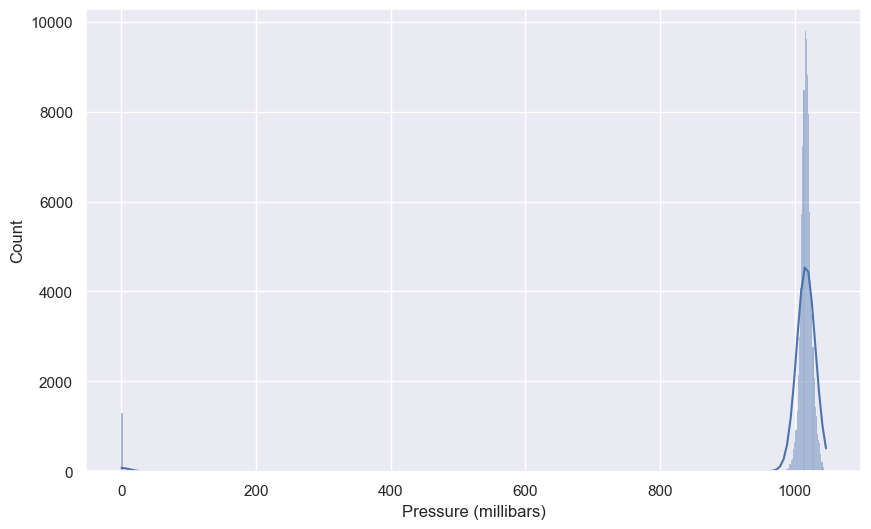

In [49]:
sns.histplot(x='Pressure (millibars)',data=df,kde=True)

In [50]:
df['Pressure (millibars)'].describe()

count    96429.000000
mean      1003.232915
std        116.984300
min          0.000000
25%       1011.900000
50%       1016.450000
75%       1021.090000
max       1046.380000
Name: Pressure (millibars), dtype: float64

#### 50% of values lie between 1011.9 and 1021.09 mb.This is a tight and stable range.Indicates most weather conditions occur under normal pressure conditions.
#### Atmospheric pressure is generally stable around 1010–1020 mb, indicating normal weather conditions dominate the dataset. However, the presence of invalid zero values significantly distorts the distribution.
#### The value 0 in Pressure (millibars) is not physically possible in real-world atmospheric conditions. Therefore, it is treated as a missing/erroneous value and replaced with NaN to maintain data accuracy during EDA

In [51]:
df[df['Pressure (millibars)'] == 0].shape[0]

1288

In [52]:
df['Pressure (millibars)'] = df['Pressure (millibars)'].replace(0, np.nan)

df['Pressure (millibars)'].describe()

count    95141.000000
mean      1016.814483
std          7.779265
min        973.780000
25%       1012.120000
50%       1016.550000
75%       1021.170000
max       1046.380000
Name: Pressure (millibars), dtype: float64

In [53]:
df['Pressure (millibars)'].isna().sum()

np.int64(1288)

## After cleaning invalid zero values

<Axes: xlabel='Pressure (millibars)', ylabel='Count'>

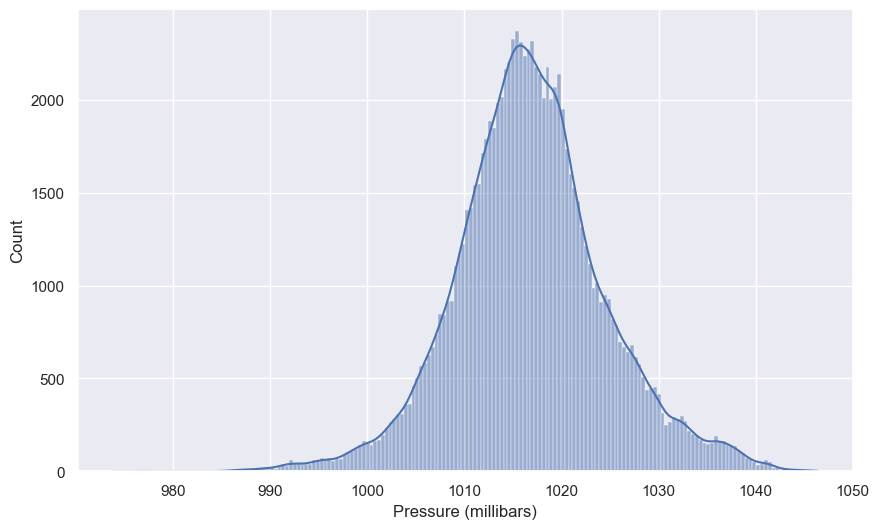

In [54]:
sns.histplot(x='Pressure (millibars)',data=df,kde=True)

In [55]:
df[df['Pressure (millibars)'] == 0].shape[0]

0

In [56]:
df['Pressure (millibars)'].describe()

count    95141.000000
mean      1016.814483
std          7.779265
min        973.780000
25%       1012.120000
50%       1016.550000
75%       1021.170000
max       1046.380000
Name: Pressure (millibars), dtype: float64

#### Pressure is a stable atmospheric feature with moderate variation.
#### After cleaning invalid zero values, atmospheric pressure shows a realistic and stable distribution centered around ~1016 mb, with moderate natural variation. The feature is now physically meaningful, statistically reliable, and highly useful for weather analysis

# **Final Univariate Analysis Summary**

#### The univariate analysis of the weather dataset was performed to understand the distribution and behavior of each individual feature, including numerical, categorical, and time-based variables.
#### Overall, the dataset shows a mix of stable climatic variables and a few highly imbalanced weather event features.
### Overall Insight
#### The dataset is well-structured and suitable for further analysis. It contains:
#### Strong numerical features with meaningful variation
#### Highly imbalanced categorical weather conditions
#### Clear temporal patterns across hours, months
#### One weak feature (cloud cover) with minimal variance
### Final Conclusion
#### The univariate analysis reveals that the weather dataset is dominated by stable atmospheric conditions with clear seasonal and temporal patterns. While numerical features show meaningful variation, categorical variables are highly imbalanced, reflecting real-world weather dominance of calm and cloudy conditions.

# **BIVARIATE ANALYSIS**

#### The purpose of bivariate analysis is to understand the relationship between temperature and other atmospheric as well as time-based variables. Through this analysis, we aim to identify how weather conditions such as humidity, pressure, wind speed, visibility, and seasonal patterns influence temperature behavior. This helps reveal meaningful environmental patterns, daily weather cycles, and seasonal climatic variations present in the dataset

##  Temperature (C) vs Summary 

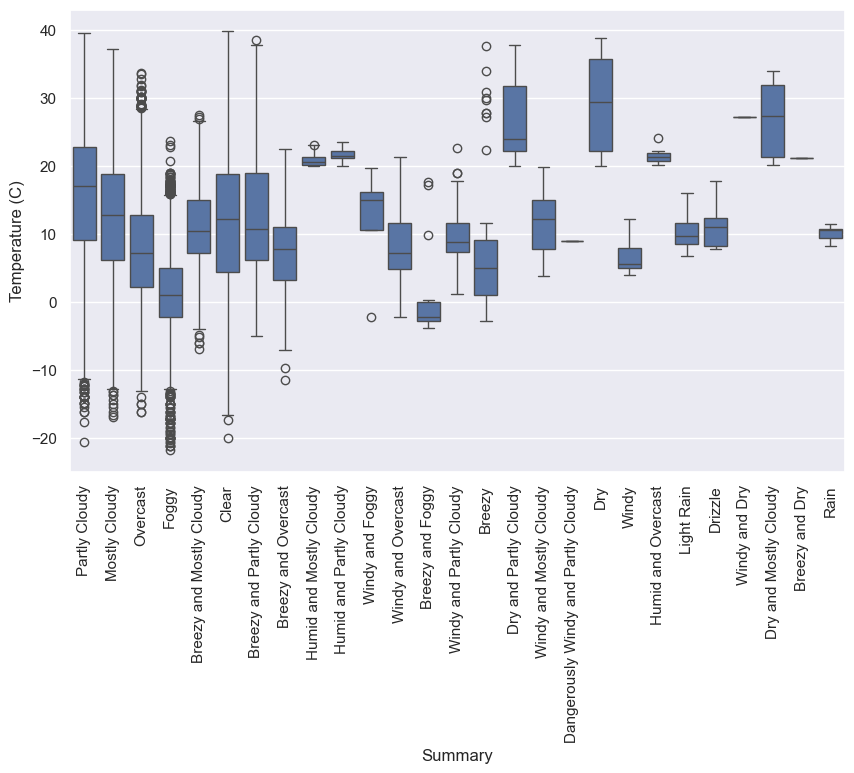

In [57]:
sns.boxplot(x='Summary',y='Temperature (C)',data=df)
plt.xticks(rotation=90)
plt.show()

In [58]:
df.groupby('Summary')['Temperature (C)'].agg(['mean','min','max','std'])

,mean,min,max,std
Summary,,,,
Breezy,7.922016,-2.777778,37.588889,10.706180
Breezy and Dry,21.111111,21.111111,21.111111,NaN
Breezy and Foggy,-0.510317,-3.827778,17.616667,5.081695
Breezy and Mostly Cloudy,11.093411,-6.966667,27.522222,6.683639
Breezy and Overcast,7.241614,-11.533333,22.433333,5.592556
Breezy and Partly Cloudy,12.492761,-5.050000,38.438889,8.140788
Clear,11.909478,-20.000000,39.905556,10.017300
Dangerously Windy and Partly Cloudy,8.944444,8.944444,8.944444,NaN
Drizzle,10.847578,7.805556,17.844444,2.485500


#### This bivariate analysis shows how temperature changes across different weather conditions. Dry weather conditions have the highest temperatures, averaging around 26–29°C, indicating hot and dry climates. Humid conditions also show relatively high and stable temperatures around 20–21°C. In contrast, foggy and overcast conditions are associated with lower temperatures, with foggy weather averaging around 1.5°C and overcast around 7–8°C, indicating colder conditions. Common weather types such as clear, partly cloudy, and mostly cloudy fall in a moderate temperature range of about 10–16°C, representing typical weather conditions in the dataset. Rain and drizzle conditions also remain in the mild temperature range around 10°C. Windy conditions show mixed behavior, with temperatures varying depending on cloud and fog combinations. Overall, the analysis clearly shows that dry weather is associated with higher temperatures, foggy and overcast weather with lower temperatures, and cloudy or clear conditions represent the most frequent and moderate climate range

##  Temperature (C) vs Precip Type               

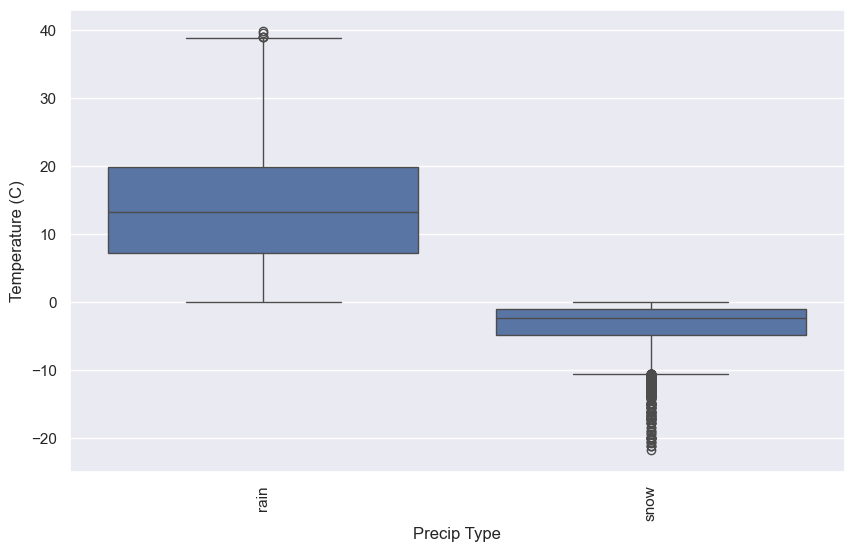

In [59]:
sns.boxplot(x='Precip Type',y='Temperature (C)',data=df)
plt.xticks(rotation=90)
plt.show()

In [60]:
df.groupby('Precip Type')['Temperature (C)'].agg(['mean','min','max','std'])

,mean,min,max,std
Precip Type,,,,
rain,13.829298,0.005556,39.905556,8.303308
snow,-3.270885,-21.822222,0.000000,3.075312


#### This analysis shows how temperature changes based on precipitation type (rain or snow).This bivariate analysis between precipitation type and temperature shows a clear relationship between the two variables. Rain is associated with higher temperatures, with an average of around 13.8°C and ranging from 0°C to 39.9°C, indicating that rainfall mostly occurs in mild to warm conditions. In contrast, snow is linked with much lower temperatures, with an average of around -3.27°C and values ranging from -21.8°C to 0°C, showing that snowfall occurs only in cold conditions.
#### Overall, the analysis clearly indicates that warmer temperatures are associated with rain, while colder temperatures are associated with snow, highlighting a strong dependency of precipitation type on temperature.


##  Temperature (C) vs Humidity 

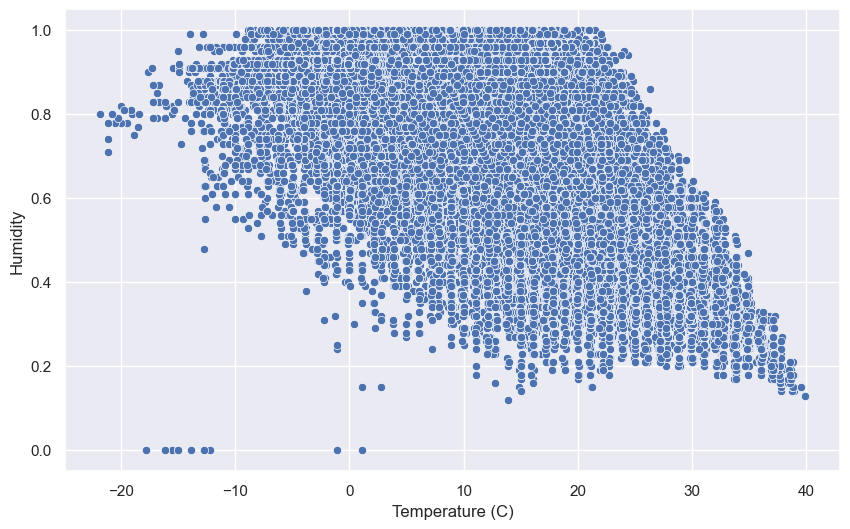

In [61]:
sns.scatterplot(x='Temperature (C)', y='Humidity',data=df)
plt.show()

In [62]:
df[['Temperature (C)', 'Humidity']].corr()

,Temperature (C),Humidity
Temperature (C),1.000000,-0.632331
Humidity,-0.632331,1.000000


#### This correlation analysis shows a moderate negative relationship between temperature and humidity. The correlation value of -0.63 indicates that when temperature increases, humidity generally decreases, and when temperature decreases, humidity tends to increase. This reflects a typical weather pattern where warmer air holds less moisture, leading to lower humidity levels, while cooler conditions are associated with higher humidity.
#### Overall, there is a clear inverse relationship between temperature and humidity in the dataset.
## The hypothesis 1 was validated during bivariate analysis using correlation analysis and scatter plots. A strong negative relationship was observed between Temperature and Relative Humidity, indicating that humidity generally decreases as temperature increases.

##  Temperature (C) vs Wind Speed (km/h)         

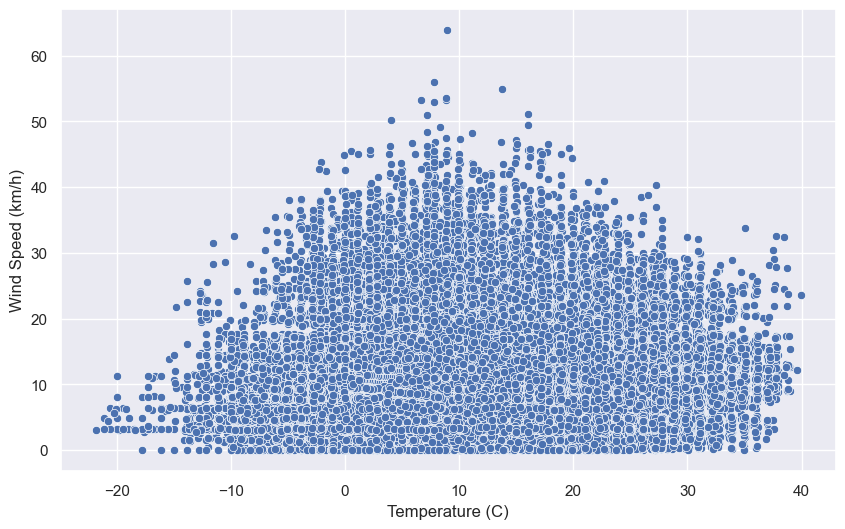

In [63]:
sns.scatterplot(x='Temperature (C)', y='Wind Speed (km/h)',data=df)
plt.show()

In [64]:
df[['Temperature (C)', 'Wind Speed (km/h)']].corr()

,Temperature (C),Wind Speed (km/h)
Temperature (C),1.000000,0.009312
Wind Speed (km/h),0.009312,1.000000


#### This correlation analysis shows that there is **almost no relationship** between temperature and wind speed. The correlation value of **0.0093** is very close to zero, which means changes in temperature do not significantly affect wind speed, and vice versa. In simple terms, wind speed and temperature behave independently in this dataset. 
#### Overall, there is **no meaningful correlation** between these two variables.


##  Temperature (C) vs Visibility (km)           

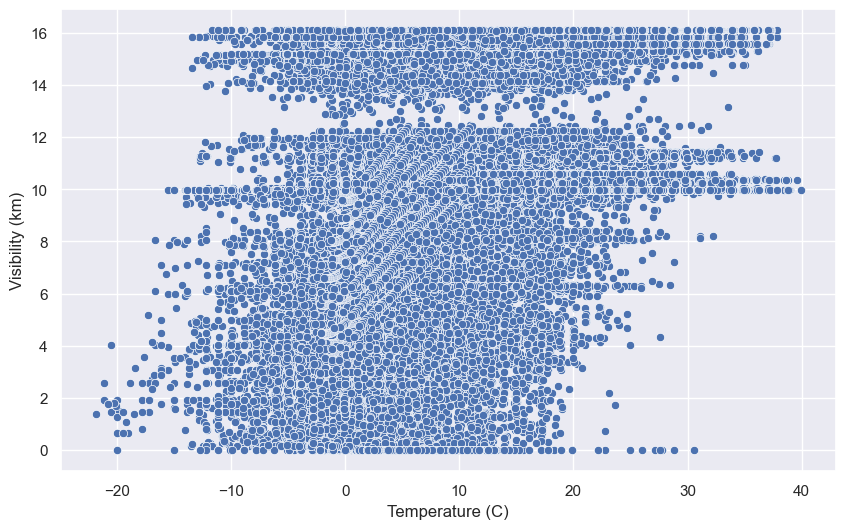

In [65]:
sns.scatterplot(x='Temperature (C)', y='Visibility (km)',data=df)
plt.show()

In [66]:
df[['Temperature (C)', 'Visibility (km)']].corr()

,Temperature (C),Visibility (km)
Temperature (C),1.000000,0.392939
Visibility (km),0.392939,1.000000


#### This correlation analysis shows a moderate positive relationship between temperature and visibility. The correlation value of 0.39 indicates that when temperature increases, visibility tends to improve slightly, and when temperature decreases, visibility generally reduces. This suggests that warmer conditions are often associated with clearer air, while colder conditions may have more fog, haze, or moisture in the atmosphere. However, the relationship is not very strong, meaning other weather factors also play an important role. Overall, there is a weak-to-moderate positive correlation between temperature and visibility.

##  Temperature (C) vs Pressure (millibars)      

<Axes: xlabel='Pressure (millibars)', ylabel='Temperature (C)'>

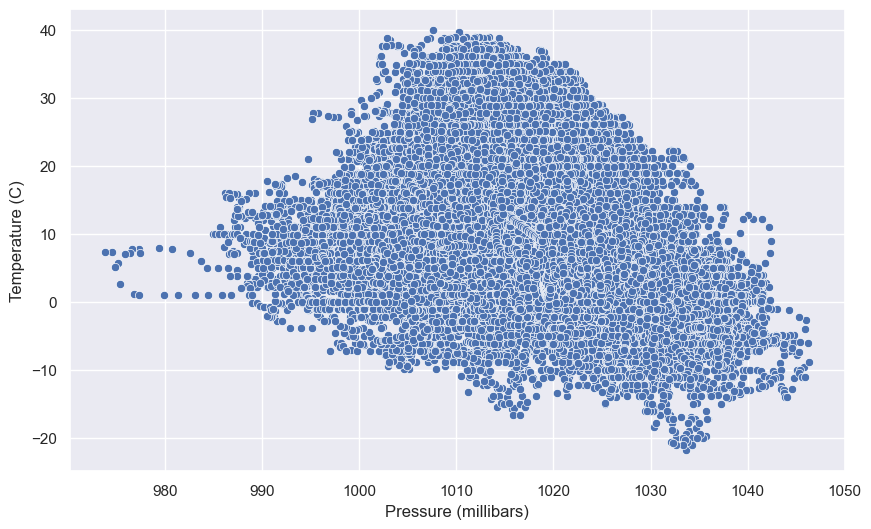

In [67]:
sns.scatterplot(x='Pressure (millibars)',y='Temperature (C)',data=df)

In [68]:
df[['Temperature (C)', 'Pressure (millibars)']].corr()

,Temperature (C),Pressure (millibars)
Temperature (C),1.000000,-0.310469
Pressure (millibars),-0.310469,1.000000


#### This correlation analysis shows a **moderate negative relationship** between temperature and pressure. The correlation value of **-0.31** indicates that when temperature increases, air pressure tends to decrease slightly, and when temperature decreases, pressure tends to increase. However, the relationship is not very strong, meaning other weather factors also influence pressure changes. 
#### Overall, the dataset shows a **slight inverse relationship between temperature and atmospheric pressure**.


##  Temperature (C) vs month

<Axes: xlabel='month', ylabel='Temperature (C)'>

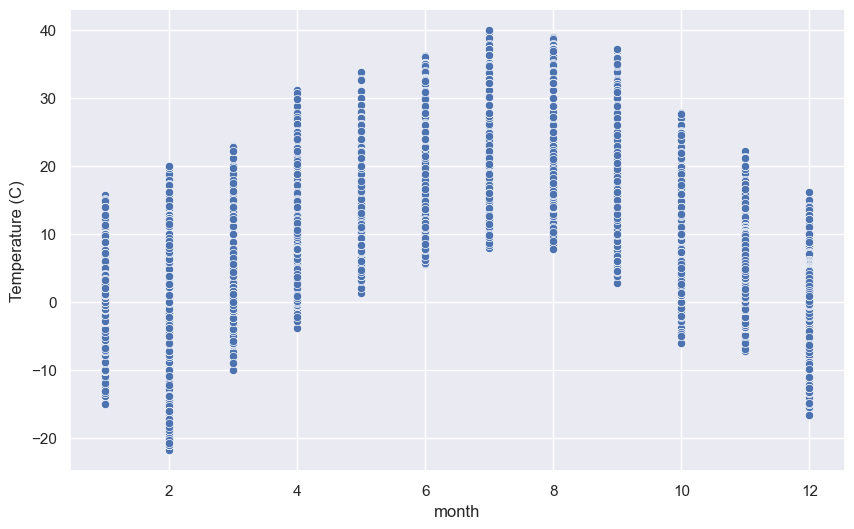

In [69]:
sns.scatterplot(x='month',y='Temperature (C)',data=df)

In [70]:
df[['Temperature (C)', 'month']].corr()

,Temperature (C),month
Temperature (C),1.00000,0.14848
month,0.14848,1.00000


#### This correlation analysis shows a very weak positive relationship between temperature and month. The correlation value of 0.15 indicates that temperature tends to increase slightly as the months progress, reflecting seasonal changes such as warmer temperatures during summer months. However, the relationship is weak, meaning temperature is not completely dependent on the month alone.

## Humidity vs Visibility

<Axes: xlabel='Humidity', ylabel='Visibility (km)'>

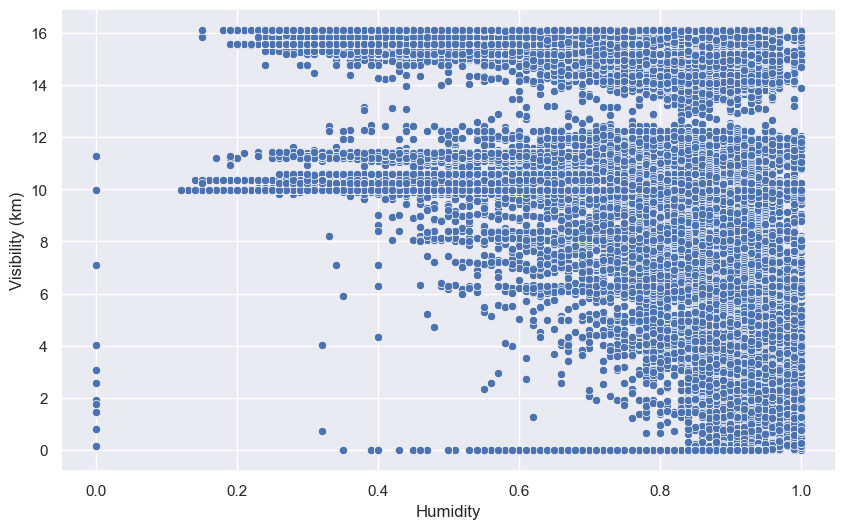

In [71]:
sns.scatterplot(x='Humidity',y='Visibility (km)',data=df)

In [72]:
df[['Humidity','Visibility (km)']].corr()

,Humidity,Visibility (km)
Humidity,1.000000,-0.369282
Visibility (km),-0.369282,1.000000


#### This correlation analysis shows a moderate negative relationship between humidity and visibility. The correlation value of -0.37 indicates that when humidity increases, visibility tends to decrease, and when humidity decreases, visibility improves. This happens because higher moisture in the air often leads to fog, haze, or cloudiness, which reduces how far we can see clearly.
#### Overall, the dataset shows that more humid conditions are generally associated with lower visibility.

## Hour vs Temperature (c)

<Axes: xlabel='hour', ylabel='Temperature (C)'>

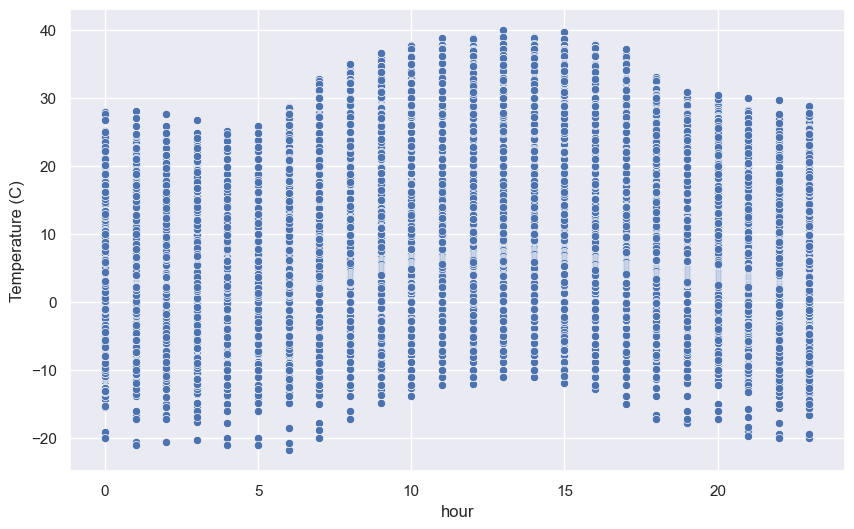

In [73]:
sns.scatterplot(x='hour',y='Temperature (C)',data=df)

In [74]:
df[['Temperature (C)','hour']].corr()

,Temperature (C),hour
Temperature (C),1.000000,0.099538
hour,0.099538,1.000000


#### This correlation analysis shows a very weak positive relationship between temperature and hour. The correlation value of 0.10 indicates that temperature increases slightly at certain hours of the day, suggesting a mild diurnal (day–night) pattern where temperatures may be higher during daytime hours. However, the relationship is weak, meaning hour alone does not strongly determine temperature. 
#### Overall, the dataset shows only a small daily time-based effect on temperature.

## month vs  Precip Type

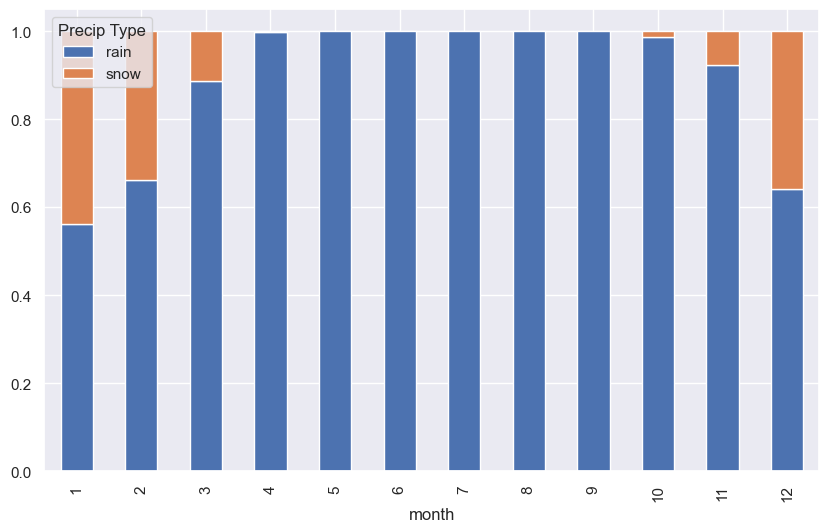

In [75]:
pd.crosstab(df['month'], df['Precip Type'], normalize='index').plot(kind='bar', stacked=True)
plt.show()

In [76]:
pd.crosstab(df['month'], df['Precip Type'], normalize='index') * 100

Precip Type,rain,snow
month,,
1,56.256109,43.743891
2,66.224544,33.775456
3,88.636364,11.363636
4,99.722222,0.277778
5,100.000000,0.000000
6,100.000000,0.000000
7,100.000000,0.000000
8,100.000000,0.000000
9,100.000000,0.000000


#### This bivariate analysis between month and precipitation type (rain/snow) shows a clear seasonal pattern in the dataset. During the summer months (May to September), precipitation is almost entirely in the form of rain (near 100%), with snow being almost absent. In contrast, the winter months (December, January, and February) show a much higher proportion of snow, especially in January and December, where snow makes up a significant share of precipitation. Transitional months like March, April, October, and November show mixed conditions, where both rain and snow are present but rain remains dominant. Overall, the results clearly indicate a strong seasonal cycle, where warmer months are associated with rain and colder months are associated with snow.

# **Final Summary of Bivariate Analysis**

#### The bivariate analysis of the weather dataset shows clear and meaningful relationships between different weather variables. Temperature is the main driver of weather patterns and shows strong and logical connections with several features. Dry conditions are associated with the highest temperatures, while foggy and overcast conditions are linked with the lowest temperatures. Rain and snow are strongly dependent on temperature, where rain occurs in warmer conditions and snow only appears in cold conditions.

#### Humidity shows a clear inverse relationship with both temperature and visibility, meaning higher humidity is linked with cooler temperatures and lower visibility. Visibility improves in warmer and less humid conditions. Wind speed and wind direction show almost no strong relationship with temperature, indicating they behave independently. Atmospheric pressure has a weak negative relationship with temperature, where higher temperatures slightly correspond to lower pressure.

#### The analysis of time-based features shows that temperature has a weak seasonal and daily pattern. Month has a small but visible effect on temperature, while hour shows a very weak diurnal effect. Precipitation type also shows a strong seasonal pattern, with rain dominating in warmer months and snow appearing mainly in winter months.
### Overall, the dataset clearly shows that **temperature and humidity are the most influential factors** in determining weather conditions, while other variables like wind and time have weaker effects. The weather patterns are consistent and follow expected real-world seasonal and atmospheric behavior.


# **MULTIVARIATE ANALYSIS**

#### Multivariate analysis is performed to understand how multiple atmospheric and time-based variables interact together to influence weather behavior. It helps identify feature dependencies, seasonal patterns, and combined environmental effects within the dataset.

# Full Correlation Matrix

In [77]:
df.corr(numeric_only=True)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Cloud Cover,Pressure (millibars),year,month,day,hour
Temperature (C),1.000000,0.992625,-0.632331,0.009312,0.029888,0.392939,NaN,-0.310469,0.017565,0.148480,-0.000313,0.099538
Apparent Temperature (C),0.992625,1.000000,-0.602641,-0.056324,0.028926,0.381804,NaN,-0.288406,0.017274,0.157892,0.002230,0.096035
Humidity,-0.632331,-0.602641,1.000000,-0.225080,0.000689,-0.369282,NaN,0.039253,0.039259,0.056543,0.004831,-0.159931
Wind Speed (km/h),0.009312,-0.056324,-0.225080,1.000000,0.103939,0.100796,NaN,-0.253791,-0.004329,-0.098810,-0.007075,0.011149
Wind Bearing (degrees),0.029888,0.028926,0.000689,0.103939,1.000000,0.047582,NaN,-0.078685,-0.025656,-0.019259,-0.003319,-0.003484
Visibility (km),0.392939,0.381804,-0.369282,0.100796,0.047582,1.000000,NaN,-0.166331,0.107317,-0.071959,-0.026343,0.103546
Cloud Cover,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pressure (millibars),-0.310469,-0.288406,0.039253,-0.253791,-0.078685,-0.166331,NaN,1.000000,-0.025511,0.114783,0.020150,-0.017189
year,0.017565,0.017274,0.039259,-0.004329,-0.025656,0.107317,NaN,-0.025511,1.000000,-0.000371,0.000301,-0.000075
month,0.148480,0.157892,0.056543,-0.098810,-0.019259,-0.071959,NaN,0.114783,-0.000371,1.000000,0.010399,-0.000002


# Correlation Heatmap

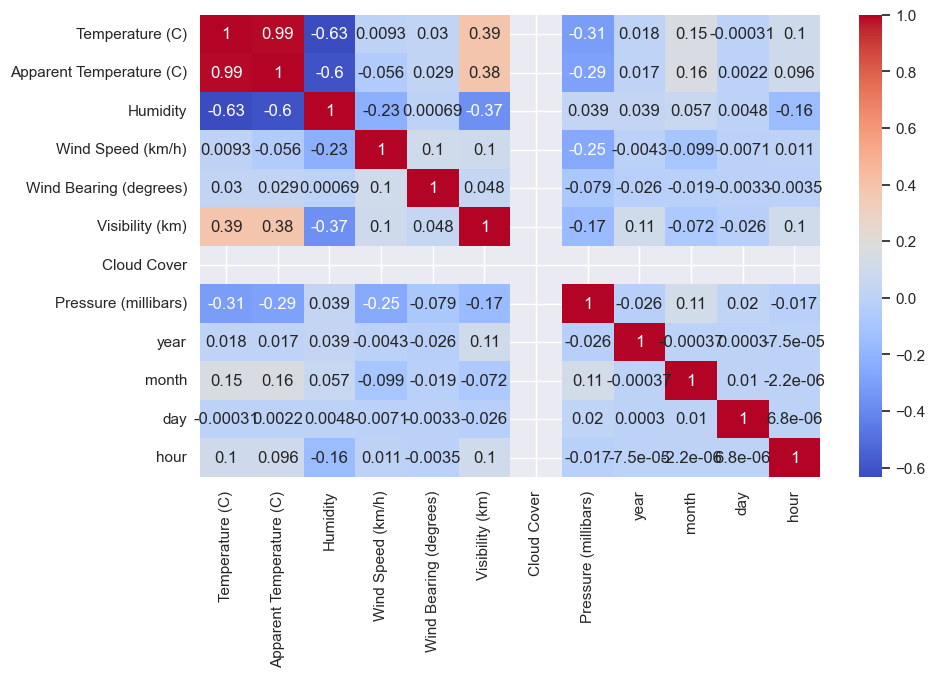

In [78]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Correlation Heatmap Summary

#### The correlation heatmap provides a visual overview of relationships between all numerical weather variables. Dark red colors represent strong positive correlations, while blue colors represent negative correlations.

#### The strongest positive relationship is observed between **Temperature** and **Apparent Temperature (~0.99)**, showing that both variables increase and decrease together almost identically. Temperature also has a strong negative correlation with **Humidity (~-0.63)**, indicating that warmer conditions are generally associated with lower humidity levels.

#### **Visibility** has a moderate positive relationship with temperature and a moderate negative relationship with humidity, meaning clearer visibility is more common in warm and less humid conditions. **Pressure** shows a weak negative relationship with temperature and wind speed, suggesting slightly lower pressure during warmer or windier weather.

#### Most wind-related variables, such as **Wind Speed** and **Wind Bearing**, show very weak correlations with other features, meaning they do not strongly influence overall weather patterns in the dataset. Time-related features like **month** and **hour** show only weak seasonal or daily effects on temperature. The **Cloud Cover** feature contains missing correlations (NaN values), indicating insufficient or unusable data.

#### The heatmap shows that the dataset is mainly driven by relationships between **temperature, humidity, apparent temperature, and visibility**, while most other variables have weak or minimal interactions. Overall, the weather patterns follow logical real-world atmospheric behavior.


# Temperature Correlation

In [79]:
df.corr(numeric_only=True)['Temperature (C)'].sort_values(ascending=False)

Temperature (C)             1.000000
Apparent Temperature (C)    0.992625
Visibility (km)             0.392939
month                       0.148480
hour                        0.099538
Wind Bearing (degrees)      0.029888
year                        0.017565
Wind Speed (km/h)           0.009312
day                        -0.000313
Pressure (millibars)       -0.310469
Humidity                   -0.632331
Cloud Cover                      NaN
Name: Temperature (C), dtype: float64

## Temperature Correlation Summary

#### This analysis shows how strongly different variables are related to **Temperature** in the dataset.

#### **Apparent Temperature (~0.99)** has the strongest positive correlation with temperature, meaning both variables behave almost identically.
#### **Visibility (~0.39)** shows a moderate positive relationship, indicating that warmer conditions are generally associated with clearer visibility.
#### **Month (~0.15)** and **Hour (~0.10)** have weak positive relationships with temperature, reflecting small seasonal and daily weather patterns.
#### **Wind Speed**, **Wind Bearing**, **Year**, and **Day** show almost no meaningful relationship with temperature.

### On the negative side:
#### **Humidity (~-0.63)** has the strongest negative correlation, meaning humidity generally decreases as temperature increases.
#### **Pressure (~-0.31)** also shows a moderate negative relationship, suggesting slightly lower atmospheric pressure during warmer conditions.
#### The **Cloud Cover** feature contains missing values (NaN), indicating insufficient data for correlation analysis.

### Overall Conclusion

#### Overall, temperature is most strongly connected with **apparent temperature, humidity, visibility, and pressure**, while most other variables have weak or negligible relationships with it.


## Hypothesis 2: Apparent Temperature vs. Actual Temperature

#### H₂: High wind speeds increase the difference between Actual Temperature and Apparent Temperature
#### This hypothesis was tested during the Multivariate Analysis phase because it involves the combined relationship between multiple variables:

#### Temperature
#### Apparent Temperature
#### Wind Speed

#### Multivariate analysis helps in understanding how multiple features together influence weather conditions.

# Feature Engineering

#### A new feature named temp_diff was created to measure the difference between Actual Temperature and Apparent Temperature.

In [84]:
df['temp_diff'] = df['Apparent Temperature (C)'] - df['Temperature (C)']

#### Reason:
#### This feature helps measure how different the “feels-like” temperature is from the actual recorded temperature.

# Relationship Analysis

#### The relationship between Wind Speed and the temperature difference was analyzed using correlation analysis and visualizations.

In [85]:
df[['Wind Speed (km/h)', 'temp_diff']].corr()

,Wind Speed (km/h),temp_diff
Wind Speed (km/h),1.00000,-0.41183
temp_diff,-0.41183,1.00000


<Axes: xlabel='temp_diff', ylabel='Wind Speed (km/h)'>

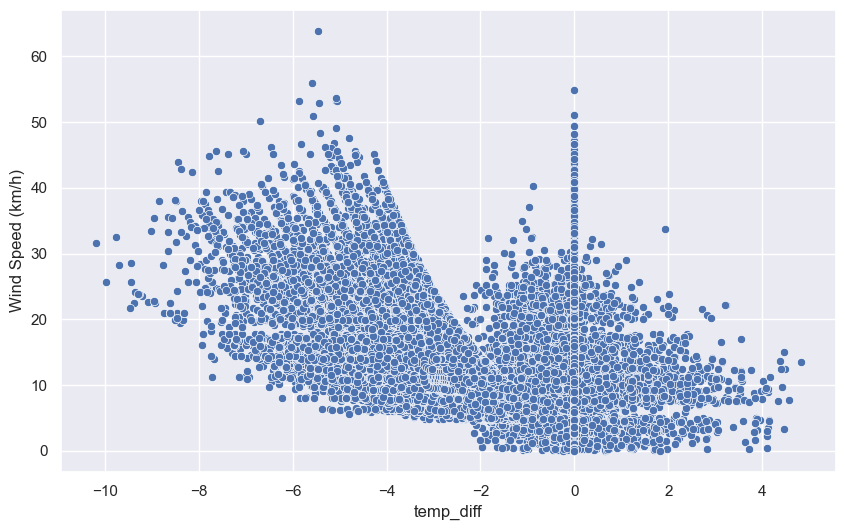

In [87]:
sns.scatterplot(x='temp_diff',y='Wind Speed (km/h)', data=df)

## Observations

#### The analysis revealed the following patterns:

#### At low wind speeds, Actual Temperature and Apparent Temperature remained nearly similar.
#### At higher wind speeds, Apparent Temperature became lower than the Actual Temperature.

#### This indicates that stronger winds make the weather feel colder than the measured air temperature.

#### Multivariate analysis was performed using Wind Speed, Actual Temperature, and Apparent Temperature. The analysis showed that as wind speed increased, the difference between actual temperature and apparent temperature also increased. This indicates the wind chill effect, where strong winds make the weather feel colder than the measured temperature. 


## Pairplot

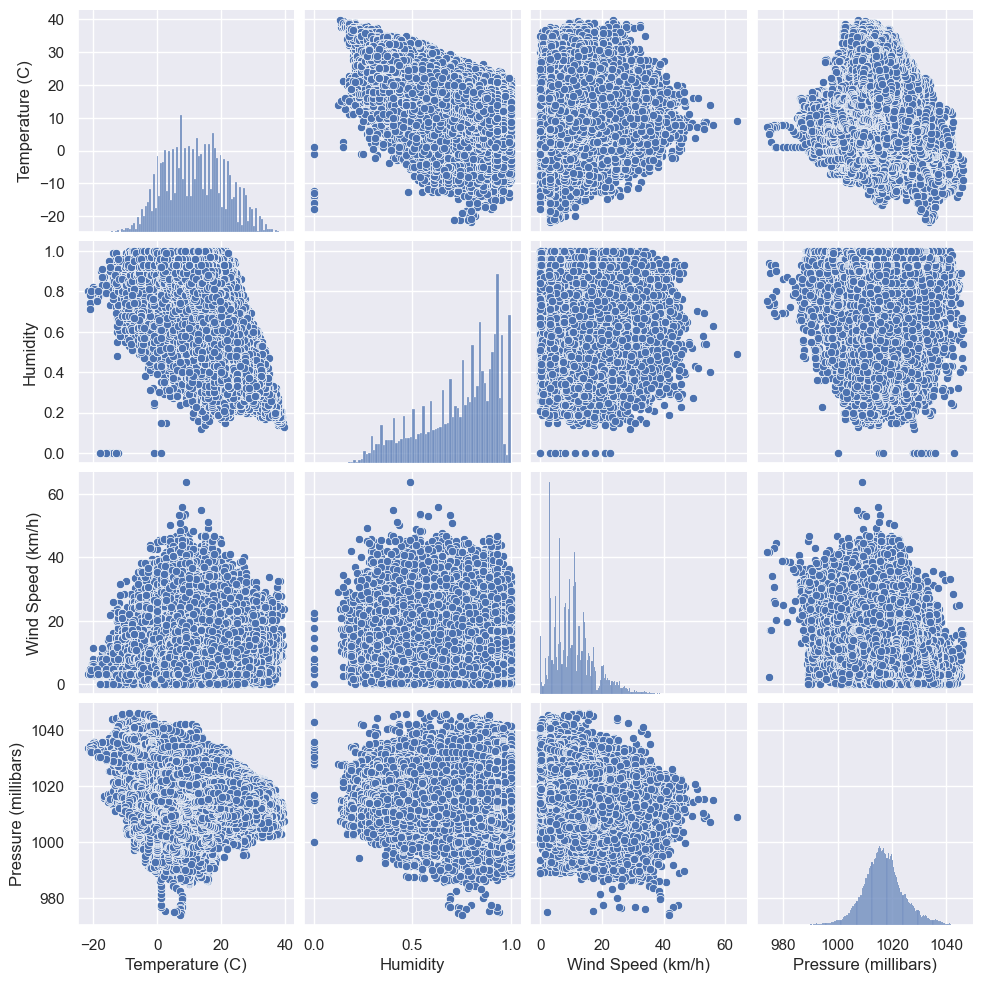

In [80]:
sns.pairplot(df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']])
plt.show()

# Grouped Multivariate Analysis

In [81]:
df.groupby('month')[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']].mean()

,Temperature (C),Humidity,Wind Speed (km/h)
month,,,
1,0.815678,0.850698,11.515865
2,2.166880,0.813407,12.180815
3,6.914976,0.702849,13.415825
4,12.769200,0.641051,11.876139
5,16.874455,0.691650,10.953186
6,20.728510,0.686418,9.632453
7,22.965462,0.639593,9.637124
8,22.334460,0.635044,8.958674
9,17.503458,0.689163,9.610204


## Monthly Weather Pattern Summary

#### This analysis shows how **temperature, humidity, and wind speed change across different months**.

#### Temperature follows a clear seasonal pattern throughout the year. The coldest months are **January and December**, with average temperatures around **1–2°C**, while the warmest months are **July and August**, where temperatures rise to around **22–23°C**. This indicates a strong transition from winter to summer seasons.

#### Humidity behaves in the opposite way compared to temperature. Winter months such as **December and January** have the highest humidity levels (0.85–0.87), while summer months like **July and August** show lower humidity (~0.63–0.64). This suggests that colder weather is generally more humid, while warmer weather is relatively drier.

#### Wind speed remains fairly stable throughout the year, mostly ranging between **9–13 km/h**. Slightly higher wind speeds are observed during late winter and early spring months, while summer months experience relatively calmer wind conditions.


#### The dataset shows a clear seasonal climate cycle:

####  Winter months → colder and more humid
####  Summer months → warmer and less humid
####  Wind speed remains mostly moderate throughout the year

### Overall, temperature and humidity display strong seasonal variation, while wind speed changes only slightly across months.


#### The monthly weather pattern analysis further supported the **seasonality hypothesis 3**. Humidity levels showed clear variation across different months and seasons. Winter months exhibited higher humidity levels, while summer months showed comparatively lower humidity. This confirms that atmospheric moisture is strongly influenced by seasonal climatic changes.

# Pivot Table

In [82]:
df.pivot_table(values='Temperature (C)',
               index='month',
               columns='Precip Type',
               aggfunc='mean')

Precip Type,rain,snow
month,,
1,4.223430,-3.566806
2,5.208673,-3.797256
3,8.065434,-2.058590
4,12.808118,-1.202273
5,16.874455,NaN
6,20.728510,NaN
7,22.965462,NaN
8,22.334460,NaN
9,17.503458,NaN


## Monthly Temperature Pattern by Precipitation Type

#### This analysis shows how temperature changes across months for both **rain** and **snow** conditions.

#### Rain occurs throughout the year and follows a clear seasonal temperature pattern. The average temperature during rainy conditions is lowest in **winter months** such as January and December (4–5°C) and gradually increases toward summer, reaching the highest values in **July and August (22–23°C)**. This indicates that rainfall is common in both cold and warm seasons but becomes warmer during summer months.

#### Snow is mainly concentrated in colder months. Snow-related temperatures remain below 0°C in almost all months where snowfall occurs, with the coldest conditions observed during **January, February, and December (-3 to -4°C)**. Snow is completely absent during warmer months from **May to September**, which is why those months contain missing values (NaN).

#### The analysis clearly highlights a strong seasonal relationship between precipitation type and temperature:

####  Rain occurs across all seasons but becomes warmer in summer months
####  Snow occurs only in very cold conditions and disappears during warm months

### Overall, temperature plays a major role in determining whether precipitation falls as rain or snow throughout the year.


# Multi-feature Visualization

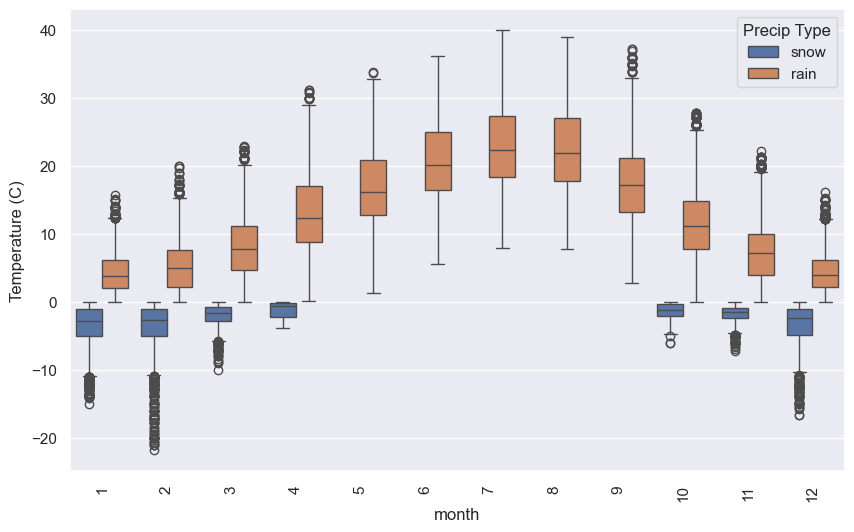

In [83]:
sns.boxplot(x=df['month'], y=df['Temperature (C)'], hue=df['Precip Type'])
plt.xticks(rotation=90)
plt.show()

## Multi-Feature Visualization Summary

#### This boxplot visualizes the relationship between **Month, Temperature, and Precipitation Type (Rain/Snow)** simultaneously.

#### The plot clearly shows a strong seasonal weather pattern throughout the year. Rain-related temperatures gradually increase from winter to summer, reaching their highest levels during **June, July, and August**, and then decrease again toward winter months. Rain occurs across almost all months, but temperatures during rainy conditions are much warmer in summer.

#### Snow-related temperatures remain consistently below 0°C and are mostly concentrated in colder months such as **January, February, November, and December**. Snow is nearly absent during summer months, confirming that snowfall only occurs under cold temperature conditions.

#### The boxplot also shows temperature variability:

#### * Summer months have a wider spread of warm temperatures
#### * Winter months contain colder temperatures and more extreme low-temperature outliers
#### * Rain has much larger temperature variation compared to snow

#### The visualization clearly demonstrates that:

####  Rain is associated with warmer temperatures and occurs throughout most of the year
####  Snow is limited to cold winter months with sub-zero temperatures
#### Temperature strongly influences both seasonal patterns and precipitation type

### Overall, the dataset follows realistic seasonal climate behavior with clear separation between rain and snow conditions.


# **Final Summary — Multivariate Analysis**

#### The multivariate analysis provides a comprehensive understanding of how multiple weather variables interact with each other across different seasons and weather conditions. The analysis shows that **temperature is the central factor influencing overall weather behavior** in the dataset.

#### A very strong positive relationship is observed between **Temperature** and **Apparent Temperature**, indicating that both variables follow nearly identical patterns. In contrast, **Humidity** has a strong negative relationship with temperature, meaning warmer conditions are generally associated with lower humidity levels. **Visibility** improves in warmer and less humid conditions, while foggy or highly humid environments are associated with reduced visibility.

#### The analysis also highlights clear seasonal weather patterns. Summer months are characterized by **high temperatures, lower humidity, and rainfall**, whereas winter months show **low temperatures, higher humidity, and snowfall**. Snow occurs only under cold or sub-zero temperature conditions and is mainly concentrated in winter months, while rain is observed throughout most of the year and becomes warmer during summer seasons.

#### Wind-related features such as **Wind Speed** and **Wind Bearing** show relatively weak relationships with other variables, suggesting that they have limited influence on overall weather variation. Atmospheric pressure shows a mild inverse relationship with temperature, where warmer conditions are slightly associated with lower pressure levels.

#### The multi-feature visualizations further confirm that **temperature strongly controls precipitation type and seasonal climate behavior**. Rain exhibits a wide temperature range across different months, while snow remains restricted to colder conditions only.

#### Overall, the dataset demonstrates realistic and consistent weather behavior, where **temperature, humidity, visibility, and precipitation type are the most interconnected variables**. The analysis clearly reflects natural seasonal climate patterns and provides valuable insights into how different atmospheric factors combine to influence weather conditions throughout the year.


## Hypothesis Testing Summary

#### The exploratory data analysis successfully validated all proposed hypotheses through statistical analysis, correlation studies, and multivariate visualizations.

### Validated Hypotheses
#### H₁: Temperature vs. Humidity
#### A strong negative relationship was observed between Temperature and Relative Humidity, indicating that humidity generally decreases as temperature increases.
#### H₂: Apparent Temperature vs. Actual Temperature
#### The analysis showed that higher wind speeds increased the difference between Actual Temperature and Apparent Temperature, supporting the wind chill effect.
#### H₃: Seasonality and Humidity Variation
#### Significant variation in humidity levels was observed across different seasons and months, confirming the impact of seasonal climate patterns on atmospheric moisture.
### Overall Interpretation

#### The analysis revealed strong seasonal and atmospheric relationships among weather variables. Temperature, humidity, wind speed, and apparent temperature demonstrated meaningful interactions that aligned with real-world meteorological behavior. The findings confirmed that the dataset follows consistent climatic patterns and provides reliable insights into seasonal weather dynamics.

# **Business Impact**
#### Improved Forecasting Models: Better understanding of weather drivers enhances prediction accuracy.
#### Disaster Preparedness: Helps identify periods of heavy snow or extreme weather for early planning.
#### Transport Optimization: Airlines and logistics can reduce delays by planning around seasonal weather patterns.
#### Agricultural Planning: Farmers can align crop cycles with expected weather conditions.
#### Infrastructure Planning: Supports better management of drainage, heating, and road systems.
#### Energy Demand Forecasting: Helps predict electricity demand based on seasonal temperature changes.

# **Final Summary – Weather Dataset EDA**

### The exploratory data analysis (EDA) of the weather dataset was performed in three stages: univariate, bivariate, and multivariate analysis. The goal was to understand the structure of the data, identify patterns, and study relationships between different weather-related variables.
### **Observations from Univariate Analysis**
#### Univariate analysis confirmed that the dataset is highly time-dependent and influenced by seasonal changes.
### **Insights from Bivariate Analysis**
#### bivariate analysis highlighted that temperature and season are key drivers of weather patterns.
### **Insights from Multivariate Analysis**
#### This analysis clearly shows that weather behavior cannot be explained by a single variable; instead, it is the result of multiple interacting factors.
# **Final Conclusion**

### The exploratory data analysis reveals that:

#### Weather patterns in the dataset are highly seasonal and structured.
#### Temperature is the most important factor influencing weather conditions.
#### Precipitation type is strongly dependent on temperature and season.
#### Multivariate relationships provide the most complete and realistic understanding of weather behavior.
